In [ ]:
# Instalación de librerías
!pip install openpyxl --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#empezamos cargando el dataset, proveniente del archivo excel
df = pd.read_excel('Calidad_Agua_subterranea_2012_2024.xlsx', sheet_name = 'CASUB_12-2024')
#ahora seleccionamos 10 variables que tengan si u si datos faltantes
#5 categoricas y 5 numericas (con sus columnas calidad correspondientes)
var_numericas = ['ALC_mg/L', 'CONDUCT_mS/cm', 'SDT_mg/L', 'FLUORUROS_mg/L', 'DUR_mg/L']
var_categoricas = ['CALIDAD_ALC', 'CALIDAD_CONDUC', 'CALIDAD_SDT_ra', 'CALIDAD_FLUO', 'CALIDAD_DUR']
#creamos el dataframe que usaremos para la tarea
df_tarea = df[var_numericas + var_categoricas].copy()
#vamos a imprimir sus dimensiones con el metodo shape()
print(f"Dimensiones del df: {df_tarea.shape}")
#tambien vamos a ver cuantos datos faltantes hay con el metodo de isnull y sum
print(f"Datos faltantes por columna: \n {df_tarea.isnull().sum()}")
#vemos por si acaso los tipos de variables o datos de cada columna
print(f"Tipo de dato por columna: \n {df_tarea.dtypes}")
#y ya imprimimos el dataframe
df_tarea.head()


Dimensiones del df: (2728, 10)
Datos faltantes por columna: 
 ALC_mg/L           91
CONDUCT_mS/cm      50
SDT_mg/L           90
FLUORUROS_mg/L    213
DUR_mg/L           63
CALIDAD_ALC        91
CALIDAD_CONDUC     50
CALIDAD_SDT_ra     90
CALIDAD_FLUO      213
CALIDAD_DUR        63
dtype: int64
Tipo de dato por columna: 
 ALC_mg/L           object
CONDUCT_mS/cm     float64
SDT_mg/L           object
FLUORUROS_mg/L     object
DUR_mg/L           object
CALIDAD_ALC        object
CALIDAD_CONDUC     object
CALIDAD_SDT_ra     object
CALIDAD_FLUO       object
CALIDAD_DUR        object
dtype: object


,ALC_mg/L,CONDUCT_mS/cm,SDT_mg/L,FLUORUROS_mg/L,DUR_mg/L,CALIDAD_ALC,CALIDAD_CONDUC,CALIDAD_SDT_ra,CALIDAD_FLUO,CALIDAD_DUR
0,139.7,884.0,562.4,0.82,505.8,Media,Permisible para riego,Cultivos sensibles,Potable - Óptima,Muy dura e indeseable usos industrial y domestico
1,148.645,329.0,184.6,0.52,132,Media,Buena para riego,Excelente para riego,Media,Potable - Dura
2,205.02,615.0,378,0.43,230,Alta,Buena para riego,Excelente para riego,Media,Potable - Dura
3,229.14,602.0,322,0.5,221.7114,Alta,Buena para riego,Excelente para riego,Media,Potable - Dura
4,168.4,379.0,239.6,0.566,152,Alta,Buena para riego,Excelente para riego,Media,Potable - Dura


In [ ]:
#empezamos transformando los datos, de tipo objeto a integer para poder hacer los calculos que haremos despues
df_tarea[var_numericas] = df_tarea[var_numericas].apply(pd.to_numeric, errors = 'coerce')
#verificamos que se hicieron los cambios
df_tarea.dtypes

,0
ALC_mg/L,float64
CONDUCT_mS/cm,float64
SDT_mg/L,float64
FLUORUROS_mg/L,float64
DUR_mg/L,float64
CALIDAD_ALC,object
CALIDAD_CONDUC,object
CALIDAD_SDT_ra,object
CALIDAD_FLUO,object
CALIDAD_DUR,object


In [ ]:
#sacamos la media, mediana, varianza y desviacion estandar de los datos numericos
for col in var_numericas:
  print(f"Media de {col}: {df_tarea[col].mean():.3f}")
print("\n")
for col in var_numericas:
  print(f"Mediana de {col}: {df_tarea[col].median():.3f}")
print("\n")
for col in var_numericas:
  print(f"Varianza de {col}: {df_tarea[col].var():.3f}")
print("\n")
for col in var_numericas:
  print(f"Desviacion estandar de {col}: {df_tarea[col].std():.3f}")

Media de ALC_mg/L: 229.748
Media de CONDUCT_mS/cm: 1040.949
Media de SDT_mg/L: 749.432
Media de FLUORUROS_mg/L: 1.058
Media de DUR_mg/L: 332.113


Mediana de ALC_mg/L: 211.890
Mediana de CONDUCT_mS/cm: 721.000
Mediana de SDT_mg/L: 485.000
Mediana de FLUORUROS_mg/L: 0.588
Mediana de DUR_mg/L: 229.000


Varianza de ALC_mg/L: 14248.036
Varianza de CONDUCT_mS/cm: 1246772.151
Varianza de SDT_mg/L: 1033436.777
Varianza de FLUORUROS_mg/L: 2.488
Varianza de DUR_mg/L: 132894.810


Desviacion estandar de ALC_mg/L: 119.365
Desviacion estandar de CONDUCT_mS/cm: 1116.590
Desviacion estandar de SDT_mg/L: 1016.581
Desviacion estandar de FLUORUROS_mg/L: 1.577
Desviacion estandar de DUR_mg/L: 364.547


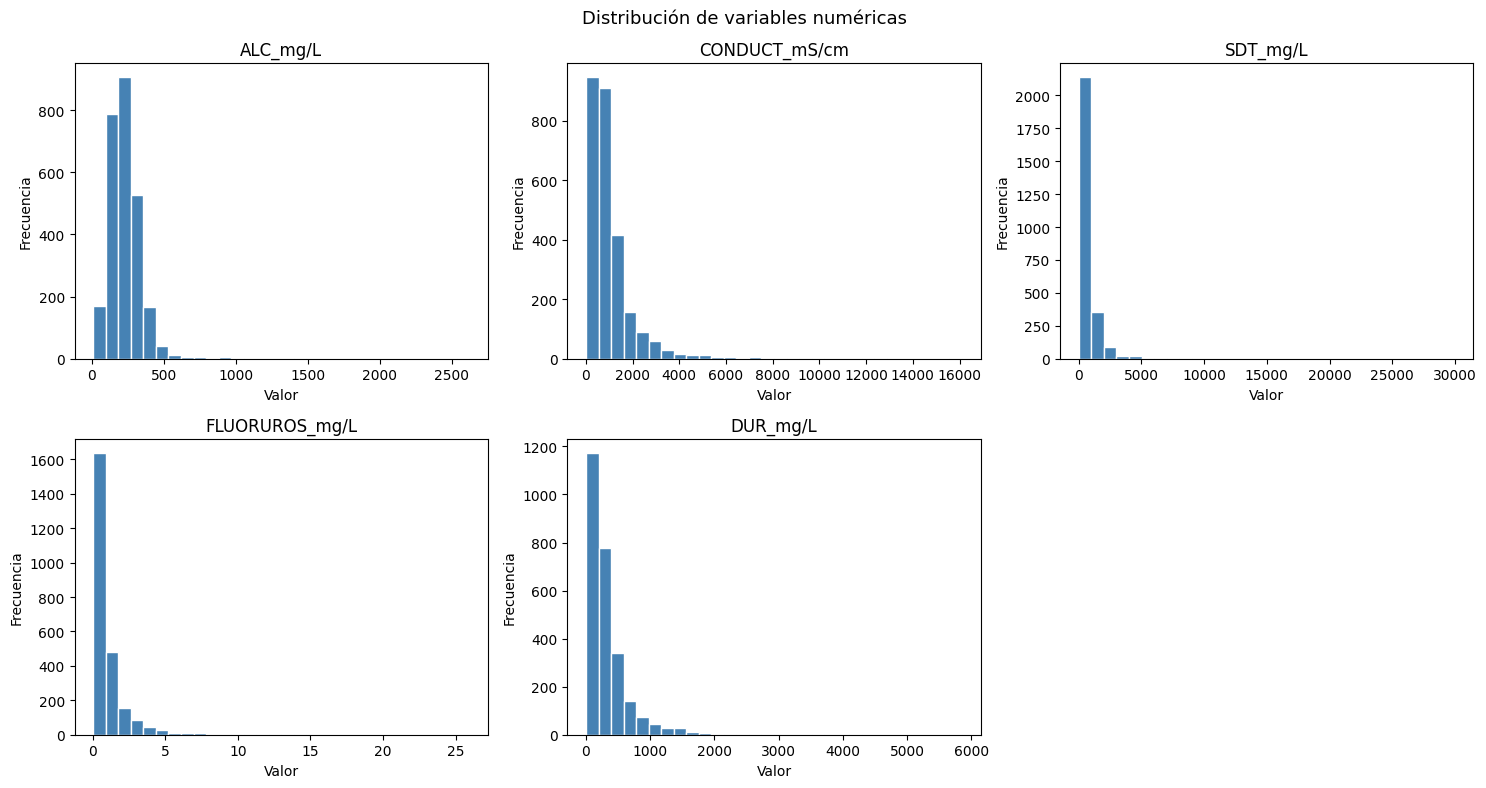

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(var_numericas):
    axes[i].hist(df_tarea[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

axes[-1].axis('off')  # oculta el panel vacío (son 5 vars en 6 espacios)
plt.suptitle('Distribución de variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

todas están fuertemente sesgadas a la derecha (right-skewed), con la mayoría de los pozos concentrados en valores bajos y una cola larga de pocos pozos con valores extremos.

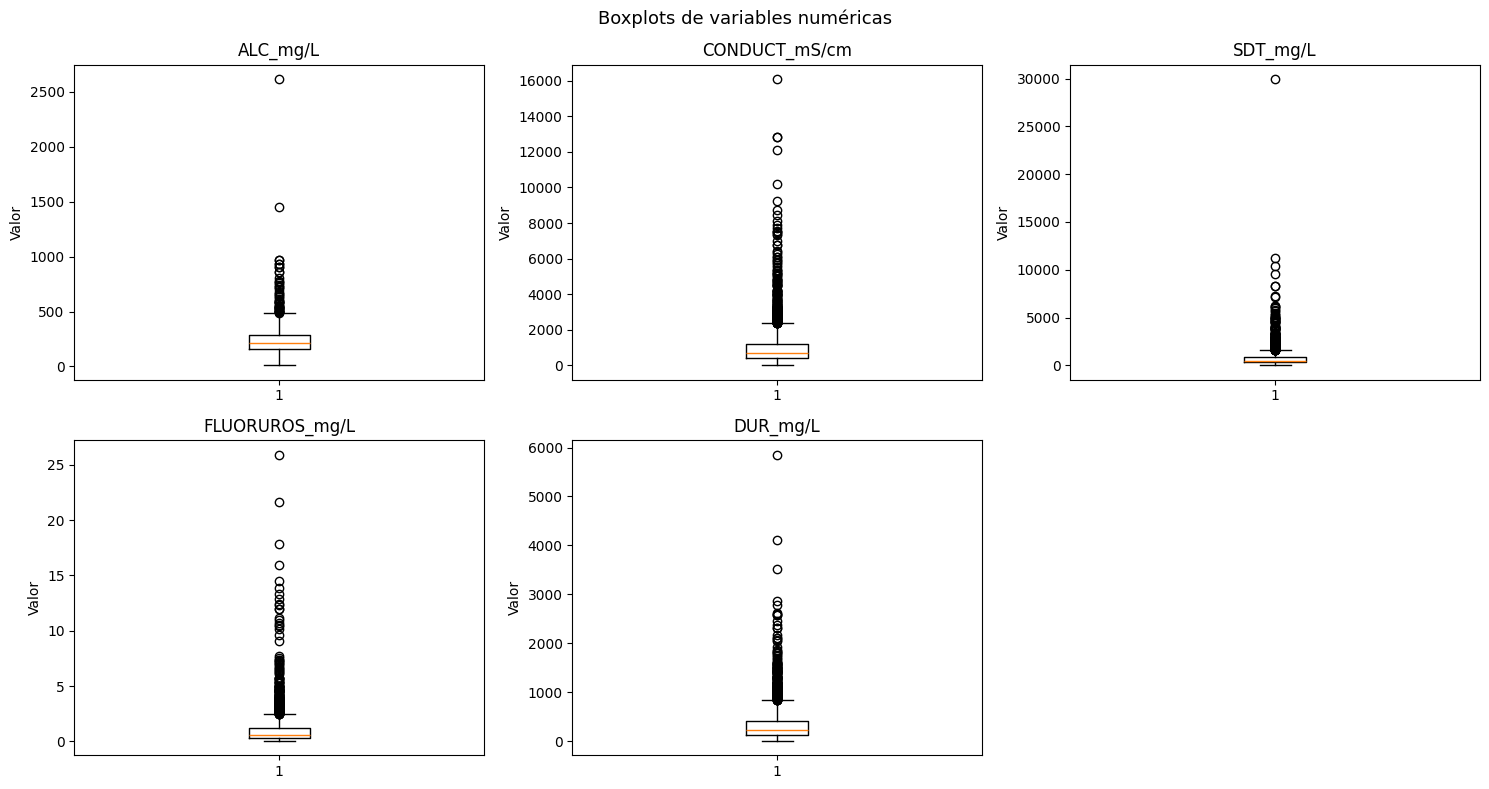

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(var_numericas):
    axes[i].boxplot(df_tarea[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')

axes[-1].axis('off')
plt.suptitle('Boxplots de variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

Este boxplot confirma y cuantifica lo que ya sospechábamos con los histogramas: outliers masivos en las 5 variables, aunque en distinta magnitud.

In [ ]:
for col in var_categoricas:
  print(f"{col}")
  print(f"Moda: {df_tarea[col].mode()}")

CALIDAD_ALC
Moda: 0    Alta
Name: CALIDAD_ALC, dtype: object
CALIDAD_CONDUC
Moda: 0    Buena para riego
Name: CALIDAD_CONDUC, dtype: object
CALIDAD_SDT_ra
Moda: 0    Excelente para riego
Name: CALIDAD_SDT_ra, dtype: object
CALIDAD_FLUO
Moda: 0    Baja
Name: CALIDAD_FLUO, dtype: object
CALIDAD_DUR
Moda: 0    Potable - Dura
Name: CALIDAD_DUR, dtype: object


In [ ]:
#vamos a empezar a imputar los datos faltantes, ya que en la graficas anteriores se ve u nota claramente que todas las variables tienen sesgo
#a la derecha y bastantes outliners, se hara esto con la mediana en lugar de la media ya que esta es afectada por lo valores externos
for col in var_numericas:
  df_tarea[col] = df_tarea[col].fillna(df_tarea[col].median())
#verificamos
df_tarea.isnull().sum()

,0
ALC_mg/L,0
CONDUCT_mS/cm,0
SDT_mg/L,0
FLUORUROS_mg/L,0
DUR_mg/L,0
CALIDAD_ALC,91
CALIDAD_CONDUC,50
CALIDAD_SDT_ra,90
CALIDAD_FLUO,213
CALIDAD_DUR,63


In [ ]:
#vamos a hacer lo mismo con las categoricas, en este caso es la moda
for col in var_categoricas:
  df_tarea[col] = df_tarea[col].fillna(df_tarea[col].mode()[0])
#verificamos
df_tarea.isnull().sum()

,0
ALC_mg/L,0
CONDUCT_mS/cm,0
SDT_mg/L,0
FLUORUROS_mg/L,0
DUR_mg/L,0
CALIDAD_ALC,0
CALIDAD_CONDUC,0
CALIDAD_SDT_ra,0
CALIDAD_FLUO,0
CALIDAD_DUR,0


vemos en la celda anterior que ya no tenemos valores vacios o NA

Ahora aplicaremos tambien una tecnica de escalamiento, en este caso la estandarizacion o Z-SCORE

In [ ]:
for col in var_numericas:
  df_tarea[col] = (df_tarea[col] - df_tarea[col].mean()) / df_tarea[col].std()

#verificamos
df_tarea[var_numericas].describe()

,ALC_mg/L,CONDUCT_mS/cm,SDT_mg/L,FLUORUROS_mg/L,DUR_mg/L
count,2.728000e+03,2.728000e+03,2.728000e+03,2.728000e+03,2.728000e+03
mean,-5.209258e-18,-1.041852e-17,4.167406e-17,-4.167406e-17,-3.125555e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.861139e+00,-9.248662e-01,-7.342017e-01,-6.481499e-01,-9.046119e-01
25%,-6.002846e-01,-5.307251e-01,-4.245835e-01,-4.454315e-01,-5.799761e-01
50%,-1.469258e-01,-2.836906e-01,-2.554055e-01,-2.829208e-01,-2.781234e-01
75%,4.660483e-01,1.534725e-01,5.471245e-02,3.756708e-02,1.975695e-01
max,2.037334e+01,1.360708e+01,2.922844e+01,1.651147e+01,1.537901e+01


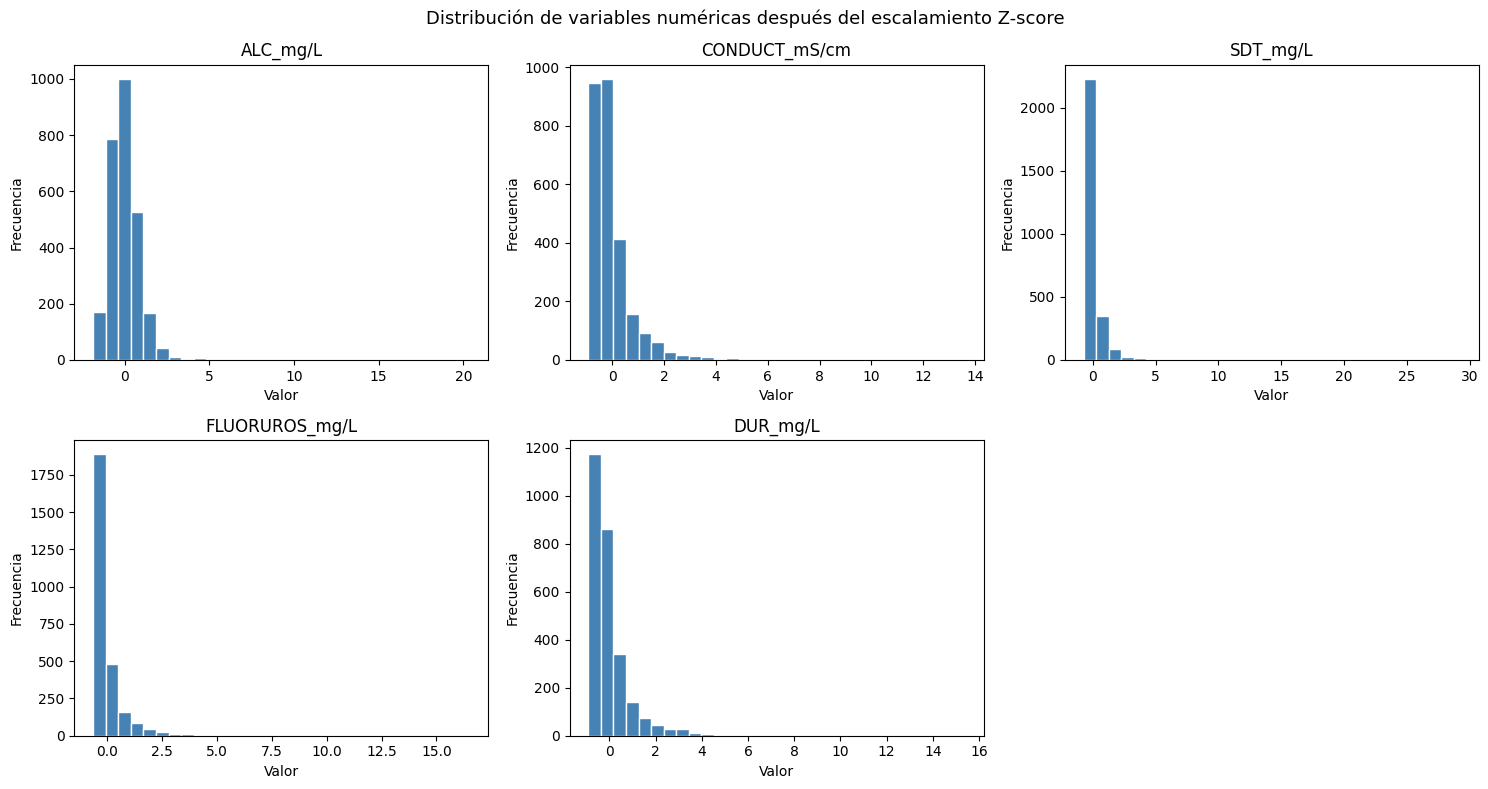

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(var_numericas):
    axes[i].hist(df_tarea[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

axes[-1].axis('off')  # oculta el panel vacío (son 5 vars en 6 espacios)
plt.suptitle('Distribución de variables numéricas después del escalamiento Z-score', fontsize=13)
plt.tight_layout()
plt.show()

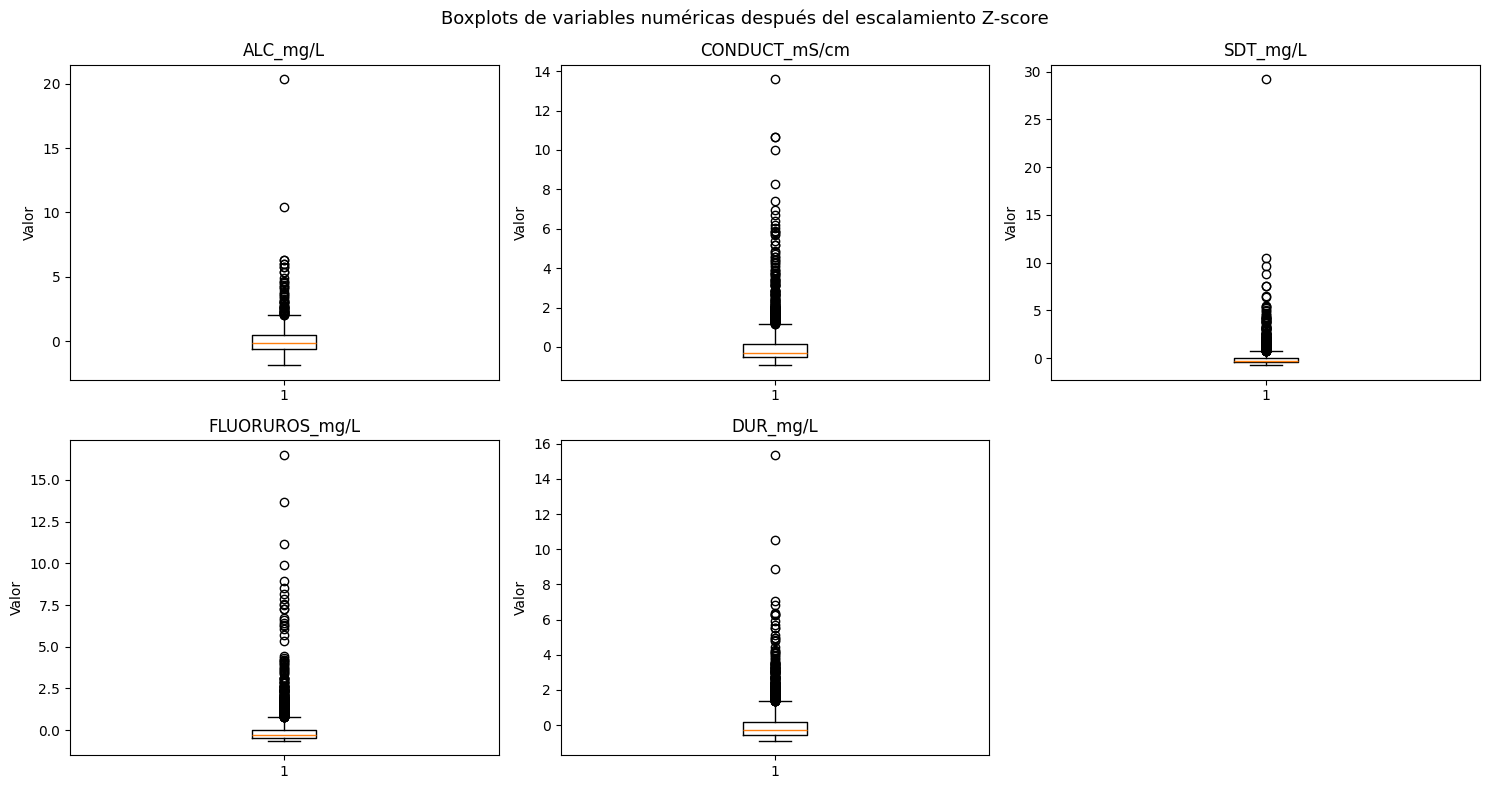

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(var_numericas):
    axes[i].boxplot(df_tarea[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')

axes[-1].axis('off')
plt.suptitle('Boxplots de variables numéricas después del escalamiento Z-score', fontsize=13)
plt.tight_layout()
plt.show()